# Regresión Polinomial — Online News Popularity

**Dataset:** Online News Popularity  
**Fuente:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/332/online+news+popularity  


---
## Descripción del problema

El dataset contiene **39,644 artículos** publicados en Mashable.com entre 2013 y 2015, con **60 características numéricas** (n=60 ≥ 20) que describen cada artículo (palabras clave, sentimiento, multimedia, día de publicación, etc.).

**Objetivo:** Predecir el número de **shares** (popularidad/veces compartido) de un artículo usando regresión polinomial.

Se implementan **tres modelos** siguiendo la misma estructura del cuadernillo de clase:
1. **Modelo 1:** Regresión polinomial grado 2 con **1 característica** — Descenso por el Gradiente
2. **Modelo 2:** Regresión polinomial grado 2 con **2 características** — Descenso por el Gradiente
3. **Modelo 3:** Regresión polinomial grado 2 con **2 características** — Ecuación Normal

**Característica principal:** `kw_avg_avg` (promedio de popularidad de palabras clave), correlación más alta con shares (|r|=0.11).  
**Segunda característica:** `LDA_03` (proximidad al tópico latente 3), segunda correlación más alta (|r|=0.084).

## 1. Importación de librerías

Se importan las mismas librerías del cuadernillo de clase: `numpy` para operaciones vectoriales, `matplotlib` para graficar, y adicionalmente `pandas` para cargar el CSV.

In [1]:
# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

# Embeber graficas dentro del cuadernillo
%matplotlib inline

## 2. Carga del Dataset

Se carga el dataset `OnlineNewsPopularity.csv`. Se eliminan los espacios en los nombres de columnas
Se selecciona la **característica principal** `kw_avg_avg` (promedio del promedio de shares de las palabras clave del artículo) como variable independiente X, y `shares` como variable objetivo y.

La variable `shares` tiene una distribución muy asimétrica (max=843,300, media=3,395). Para que el gradiente converja correctamente se aplica la transformación `log(1 + shares)`, práctica estándar en este tipo de problemas de popularidad web.

In [2]:
# Cargar dataset
df = pd.read_csv('OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()  # Eliminar espacios en nombres de columnas

# Variable independiente: kw_avg_avg (promedio de popularidad promedio de palabras clave)
# Variable objetivo: log(1 + shares) para reducir el efecto de valores extremos
X = df[['kw_avg_avg']].values          # shape (m, 1)
y = np.log1p(df['shares'].values)      # log(1 + shares)
m = y.size

print(f'Número de ejemplos (m): {m}  →  m >= 20000 ✓')
print(f'Número de características disponibles: {df.shape[1]-2}  →  n >= 20 ✓')
print(f'\nPrimeros 20 valores de kw_avg_avg y log(1+shares):')
print('{:>14s}{:>18s}'.format('kw_avg_avg', 'log(1+shares)'))
print('-'*34)
for i in range(20):
    print('{:14.2f}{:18.4f}'.format(X[i, 0], y[i]))

Número de ejemplos (m): 39644  →  m >= 20000 ✓
Número de características disponibles: 59  →  n >= 20 ✓

Primeros 20 valores de kw_avg_avg y log(1+shares):
    kw_avg_avg     log(1+shares)
----------------------------------
          0.00            6.3869
          0.00            6.5681
          0.00            7.3139
          0.00            7.0909
          0.00            6.2265
          0.00            6.7523
          0.00            6.3226
          0.00            6.7935
          0.00            8.1890
          0.00            6.5667
          0.00            7.6967
          0.00            7.5501
          0.00            6.7142
          0.00            9.2104
          0.00            6.6359
          0.00            7.3784
          0.00            9.5179
          0.00            8.0395
          0.00            8.6484
          0.00            9.7469


## 3. Visualización inicial de los datos

Se define la función `plotData` para graficar los puntos del dataset. Esta función es la misma del cuadernillo de clase, adaptada a las variables del nuevo dataset.

Se grafican los primeros 2,000 puntos para no saturar la visualización (el dataset tiene ~39,000 registros).

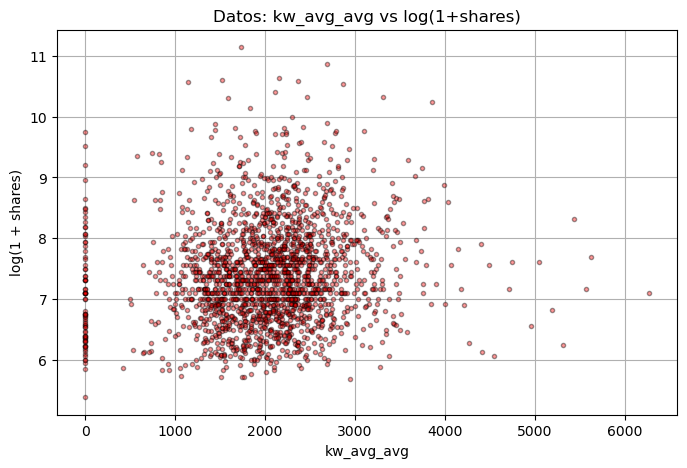

In [3]:
def plotData(x, y, titulo='', xlabel='', ylabel=''):
    """Grafica los puntos x e y en una figura nueva."""
    fig = pyplot.figure(figsize=(8, 5))
    # Se grafican solo 2000 puntos para mayor claridad visual
    pyplot.plot(x[:2000], y[:2000], 'ro', ms=3, mec='k', alpha=0.4)
    pyplot.ylabel(ylabel or 'log(1 + shares)')
    pyplot.xlabel(xlabel or 'kw_avg_avg')
    pyplot.title(titulo or 'Datos: kw_avg_avg vs log(1+shares)')
    pyplot.grid(True)
    pyplot.show()

# Visualización inicial — misma estructura que el cuadernillo de clase
plotData(X, y)

## 4. Construcción de características polinomiales

`

In [4]:
# Agregar columna x^2 — igual que en el cuadernillo de clase
X = np.concatenate([X, X * X], axis=1)

print('Matriz X con características polinomiales [kw_avg_avg, kw_avg_avg^2]:')
print(f'Shape: {X.shape}  →  {m} ejemplos, 2 características')
print('\nPrimeras 5 filas:')
print(X[:5])

Matriz X con características polinomiales [kw_avg_avg, kw_avg_avg^2]:
Shape: (39644, 2)  →  39644 ejemplos, 2 características

Primeras 5 filas:
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


## 5. Normalización de características



In [5]:
def featureNormalize(X):
    """Normaliza las columnas de X. Retorna X normalizado, mu y sigma."""
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Llamar featureNormalize con los datos cargados — mismo paso que el cuadernillo de clase
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (mu):', mu)
print('Desviación estándar (sigma):', sigma)
print('\nPrimeras 5 filas de X normalizado:')
print(X_norm[:5])

Media calculada (mu): [3.13585864e+03 1.15710860e+07]
Desviación estándar (sigma): [1.31813377e+03 2.33122619e+07]

Primeras 5 filas de X normalizado:
[[-2.37901396 -0.49635192]
 [-2.37901396 -0.49635192]
 [-2.37901396 -0.49635192]
 [-2.37901396 -0.49635192]
 [-2.37901396 -0.49635192]]


### 5.1 Visualización tras la normalización

Después de aplicar `featureNormalize`, se visualiza la segunda columna (término cuadrático normalizado) contra `log(1+shares)`. El eje X ahora está centrado en 0, lo que facilita la convergencia del gradiente.

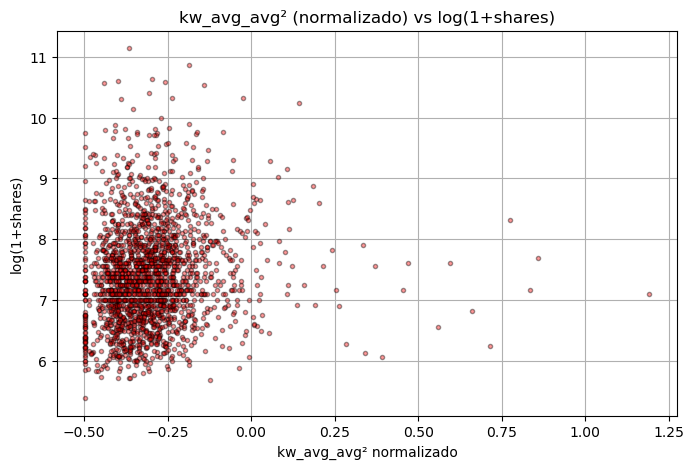

In [6]:
# Graficar la característica cuadrática normalizada vs log(1+shares)
# Mismo paso que el cuadernillo de clase: plotData(X_norm[:,1], y)
plotData(X_norm[:, 1].reshape(-1,1), y,
         titulo='kw_avg_avg² (normalizado) vs log(1+shares)',
         xlabel='kw_avg_avg² normalizado',
         ylabel='log(1+shares)')

### 5.2 Agregar columna de unos (término de intersección θ₀)

Se agrega la columna de unos a la matriz X normalizada para incluir el término independiente θ₀ en el modelo. 


La matriz final tiene forma **(m × 3)**: columna de unos, `kw_avg_avg` normalizado, `kw_avg_avg²` normalizado.

In [7]:
# Añadir el término de intersección (columna de unos para X0)
# Igual que en el cuadernillo de clase
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f'Shape final de X: {X.shape}  →  [m × 3] = [unos, kw_avg_avg_norm, kw_avg_avg²_norm]')
print('\nPrimeras 5 filas:')
print(X[:5])

Shape final de X: (39644, 3)  →  [m × 3] = [unos, kw_avg_avg_norm, kw_avg_avg²_norm]

Primeras 5 filas:
[[ 1.         -2.37901396 -0.49635192]
 [ 1.         -2.37901396 -0.49635192]
 [ 1.         -2.37901396 -0.49635192]
 [ 1.         -2.37901396 -0.49635192]
 [ 1.         -2.37901396 -0.49635192]]


## 6. Funciones de Costo y Descenso por el Gradiente

### 6.1 Función de Costo J(θ)



In [8]:
def computeCostMulti(X, y, theta):
    """Calcula la función de costo J(theta) para regresión lineal/polinomial."""
    # Inicializa algunos valores útiles
    m = y.shape[0]  # número de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

### 6.2 Descenso por el Gradiente



In [9]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """Descenso por el gradiente para regresión polinomial multivariable."""
    # Inicializa algunos valores
    m = y.shape[0]  # número de ejemplos de entrenamiento

    # Realiza una copia de theta, el cual será actualizado por el descenso
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 7. Modelo 1 — Descenso por el Gradiente (1 característica, grado 2)

### 7.1 Selección del coeficiente de aprendizaje α


- Se elige `alpha = 0.1` (tasa de aprendizaje)
- Se ejecutan `num_iters = 5000` iteraciones
- Se inicializa `theta = zeros(3)` (3 parámetros: θ₀, θ₁, θ₂)

La tasa de aprendizaje controla el tamaño de cada paso en el descenso. Si α es muy grande, el algoritmo puede divergir. Si es muy pequeño, converge lentamente.

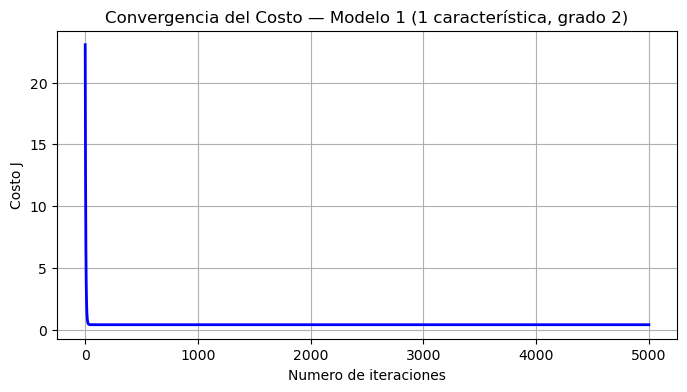

theta calculado por el descenso por el gradiente: [ 7.47569154  0.33667534 -0.16641684]
Costo final: 0.405535


In [10]:
# Elegir valor para alpha — mismo proceso que el cuadernillo de clase
alpha = 0.1
num_iters = 5000

# Inicializar theta y ejecutar el descenso por el gradiente
theta1 = np.zeros(3)
theta1, J_history1 = gradientDescentMulti(X, y, theta1, alpha, num_iters)

# Grafica la convergencia del costo — igual que en el cuadernillo de clase
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history1)), J_history1, lw=2, color='blue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo — Modelo 1 (1 característica, grado 2)')
pyplot.grid(True)
pyplot.show()

# Mostrar resultados
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta1)))
print(f'Costo final: {J_history1[-1]:.6f}')

### 7.2 Predicción con Modelo 1

Se predice el número de shares para un artículo con `kw_avg_avg = 3500` (valor cercano a la media del dataset, que es ~3,136).

**Importante:** Antes de aplicar theta, se debe normalizar el nuevo valor usando los mismos `mu` y `sigma` calculados en el entrenamiento. Luego se aplica la transformación inversa `expm1()` para obtener el número de shares estimado.

In [11]:
# Predicción para un artículo con kw_avg_avg = 3500
# Mismo proceso que el cuadernillo de clase: normalizar primero
X_pred1 = [1, 3500, 3500**2]
X_pred1[1:3] = (X_pred1[1:3] - mu) / sigma
pred_log1 = np.dot(X_pred1, theta1)
pred_shares1 = np.expm1(pred_log1)  # Transformación inversa de log(1+shares)

print(f'Para un artículo con kw_avg_avg = 3500:')
print(f'  log(1+shares) predicho : {pred_log1:.4f}')
print(f'  shares estimados       : {pred_shares1:.0f}')

Para un artículo con kw_avg_avg = 3500:
  log(1+shares) predicho : 7.5639
  shares estimados       : 1926


### 7.3 Visualización de la curva ajustada
```

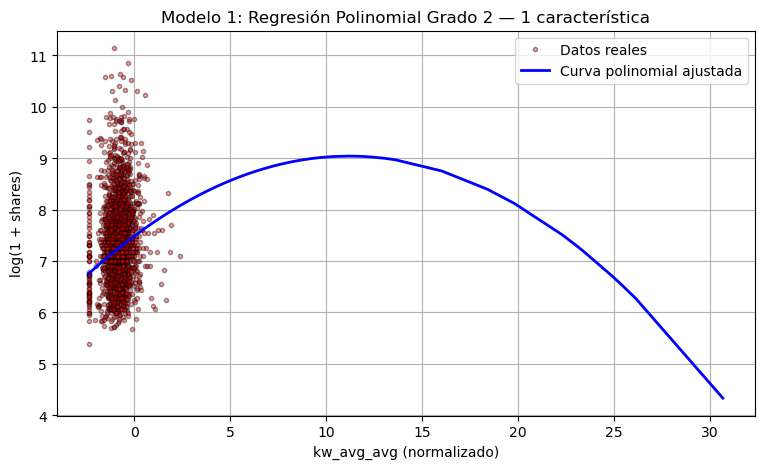

In [12]:
# Graficar datos y curva ajustada — mismo esquema del cuadernillo de clase
sort_idx = np.argsort(X[:, 1])
pyplot.figure(figsize=(9, 5))
pyplot.plot(X[:2000, 1], y[:2000], 'ro', ms=3, mec='k', alpha=0.4, label='Datos reales')
pyplot.plot(X[sort_idx, 1], np.dot(X, theta1)[sort_idx], 'b-', lw=2, label='Curva polinomial ajustada')
pyplot.xlabel('kw_avg_avg (normalizado)')
pyplot.ylabel('log(1 + shares)')
pyplot.title('Modelo 1: Regresión Polinomial Grado 2 — 1 característica')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

---
## 8. Modelo 2 — Descenso por el Gradiente 
### 8.1 Carga y preparación con 2 características

In [13]:
# Recargar datos frescos — mismo procedimiento que el cuadernillo de clase
df2 = pd.read_csv('OnlineNewsPopularity.csv')
df2.columns = df2.columns.str.strip()

# Dos características: kw_avg_avg y LDA_03
x1 = df2['kw_avg_avg'].values.reshape(-1, 1)
x2 = df2['LDA_03'].values.reshape(-1, 1)
y2 = np.log1p(df2['shares'].values)
m2 = len(y2)

# Construir matriz polinomial grado 2: [x1, x1^2, x2, x2^2]
X2_poly = np.concatenate([x1, x1**2, x2, x2**2], axis=1)

print(f'Shape de X polinomial (2 vars, grado 2): {X2_poly.shape}')
print('Columnas: [kw_avg_avg, kw_avg_avg², LDA_03, LDA_03²]')
print('\nPrimeras 3 filas:')
print(X2_poly[:3])

Shape de X polinomial (2 vars, grado 2): (39644, 4)
Columnas: [kw_avg_avg, kw_avg_avg², LDA_03, LDA_03²]

Primeras 3 filas:
[[0.         0.         0.04126265 0.00170261]
 [0.         0.         0.05010067 0.00251008]
 [0.         0.         0.03333354 0.00111112]]


### 8.2 Normalización y adición de término de intersección

In [14]:
# Normalizar características — misma función del cuadernillo de clase
X2_norm, mu2, sigma2 = featureNormalize(X2_poly)

print('mu2    =', mu2)
print('sigma2 =', sigma2)

# Agregar columna de unos
X2 = np.concatenate([np.ones((m2, 1)), X2_norm], axis=1)

print(f'\nShape final X2: {X2.shape}  →  [m × 5 parámetros: θ0..θ4]')

mu2    = [3.13585864e+03 1.15710860e+07 2.23769617e-01 1.37208212e-01]
sigma2 = [1.31813377e+03 2.33122619e+07 2.95187010e-01 2.46837269e-01]

Shape final X2: (39644, 5)  →  [m × 5 parámetros: θ0..θ4]


### 8.3 Entrenamiento con Descenso por el Gradiente y gráfica de costo

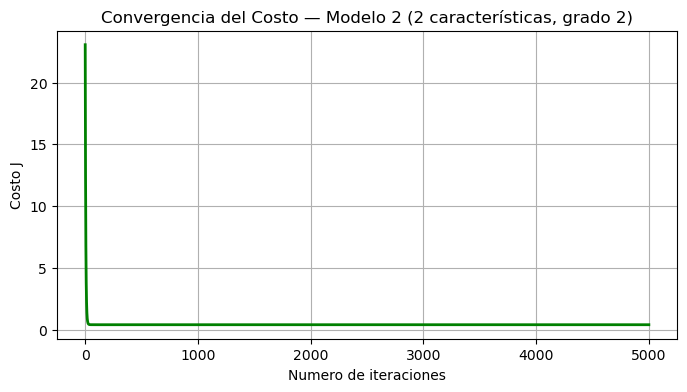

theta calculado por el descenso por el gradiente: [ 7.47569154  0.33296151 -0.16454596  0.04216723 -0.03985014]
Costo final: 0.405489


In [15]:
# Entrenamiento Modelo 2 — mismos parámetros del cuadernillo de clase
alpha2 = 0.1
num_iters2 = 5000

theta2 = np.zeros(5)
theta2, J_history2 = gradientDescentMulti(X2, y2, theta2, alpha2, num_iters2)

# Gráfica de convergencia del costo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history2)), J_history2, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo — Modelo 2 (2 características, grado 2)')
pyplot.grid(True)
pyplot.show()

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta2)))
print(f'Costo final: {J_history2[-1]:.6f}')

### 8.4 Predicción con Modelo 2

Se predice para un artículo con `kw_avg_avg = 3500` y `LDA_03 = 0.4` (valores representativos del dataset).

Para un artículo con kw_avg_avg=3500 y LDA_03=0.4:
  log(1+shares) predicho : 7.5844
  shares estimados       : 1966


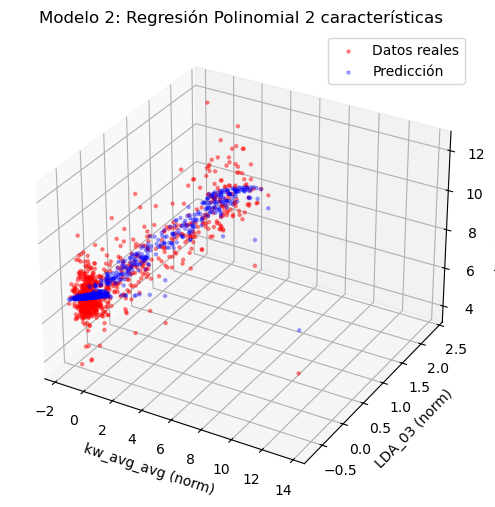

In [16]:
# Predicción con 2 características — normalizar con mu2, sigma2
X_pred2 = [1, 3500, 3500**2, 0.4, 0.4**2]
X_pred2[1:5] = (X_pred2[1:5] - mu2) / sigma2
pred_log2 = np.dot(X_pred2, theta2)
pred_shares2 = np.expm1(pred_log2)

print(f'Para un artículo con kw_avg_avg=3500 y LDA_03=0.4:')
print(f'  log(1+shares) predicho : {pred_log2:.4f}')
print(f'  shares estimados       : {pred_shares2:.0f}')

# Visualización 3D
idx_s = np.random.choice(m2, 800, replace=False)
fig = pyplot.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X2[idx_s, 1], X2[idx_s, 3], y2[idx_s], c='red', s=5, alpha=0.4, label='Datos reales')
ax.scatter(X2[idx_s, 1], X2[idx_s, 3], np.dot(X2[idx_s], theta2), c='blue', s=5, alpha=0.3, label='Predicción')
ax.set_xlabel('kw_avg_avg (norm)')
ax.set_ylabel('LDA_03 (norm)')
ax.set_zlabel('log(1+shares)')
ax.set_title('Modelo 2: Regresión Polinomial 2 características')
ax.legend()
pyplot.show()

---
## 9. Modelo 3 — Ecuación Normal 
### 9.1 Recargar datos (sin normalización) 

In [17]:
# Recargar datos para garantizar que las variables no estén modificadas
# Mismo procedimiento que el cuadernillo de clase
df3 = pd.read_csv('OnlineNewsPopularity.csv')
df3.columns = df3.columns.str.strip()

x1_raw = df3['kw_avg_avg'].values.reshape(-1, 1)
x2_raw = df3['LDA_03'].values.reshape(-1, 1)
y3 = np.log1p(df3['shares'].values)
m3 = len(y3)

# Construir matriz polinomial grado 2 SIN NORMALIZAR
# Misma instrucción del cuadernillo: X = concatenate([X, X*X], axis=1)
# luego: X = concatenate([ones, X], axis=1)
X3 = np.concatenate([
    np.ones((m3, 1)),
    x1_raw, x1_raw**2,
    x2_raw, x2_raw**2
], axis=1)

print(f'Shape de X3 (sin normalización): {X3.shape}')
print('Columnas: [1, kw_avg_avg, kw_avg_avg², LDA_03, LDA_03²]')
print('\nPrimeras 3 filas:')
print(X3[:3])

Shape de X3 (sin normalización): (39644, 5)
Columnas: [1, kw_avg_avg, kw_avg_avg², LDA_03, LDA_03²]

Primeras 3 filas:
[[1.         0.         0.         0.04126265 0.00170261]
 [1.         0.         0.         0.05010067 0.00251008]
 [1.         0.         0.         0.03333354 0.00111112]]


### 9.2 Función normalEqn y cálculo de θ


In [18]:
def normalEqn(X, y):
    """Calcula theta usando la ecuación normal: theta = (X^T X)^{-1} X^T y"""
    theta = np.zeros(X.shape[1])
    # Se usa pinv (pseudoinversa) para mayor estabilidad numérica
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# Calcular los parámetros con la ecuación de la normal
theta3 = normalEqn(X3, y3)

# Mostrar resultados — misma instrucción del cuadernillo de clase
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta3)))

Theta calculado a partir de la ecuación de la normal: [ 8.67959147e-07  2.55286923e-03 -9.64810844e-08  2.15860786e-07
  1.36192587e-07]


### 9.3 Predicción con Ecuación Normal


Para un artículo con kw_avg_avg=3500 y LDA_03=0.4:
  log(1+shares) predicho (ec. normal) : 7.7532
  shares estimados (ec. normal)       : 2328


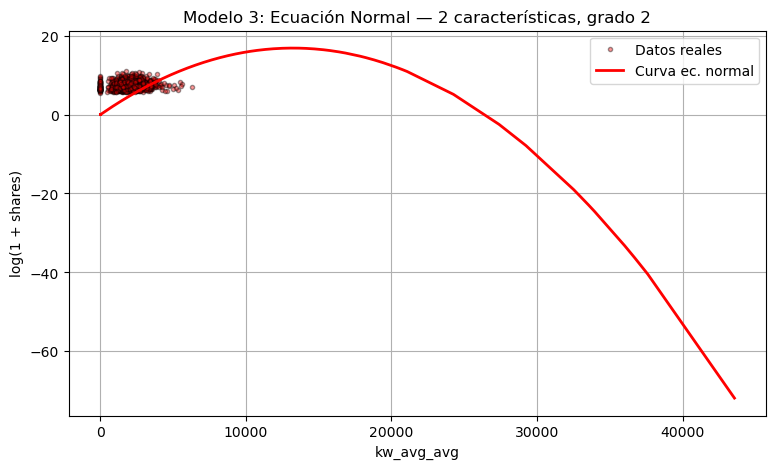

In [19]:
# Predicción para kw_avg_avg=3500 y LDA_03=0.4
# Con ecuación normal NO se normaliza — mismo esquema del cuadernillo de clase
X_pred3 = [1, 3500, 3500**2, 0.4, 0.4**2]
pred_log3 = np.dot(X_pred3, theta3)
pred_shares3 = np.expm1(pred_log3)

print(f'Para un artículo con kw_avg_avg=3500 y LDA_03=0.4:')
print(f'  log(1+shares) predicho (ec. normal) : {pred_log3:.4f}')
print(f'  shares estimados (ec. normal)       : {pred_shares3:.0f}')

# Visualización igual al cuadernillo de clase
# plotData(X[:, 1], y) + pyplot.plot(X[:, 1], dot(X, theta), '-')
sort_idx3 = np.argsort(X3[:, 1])
pyplot.figure(figsize=(9, 5))
pyplot.plot(X3[:2000, 1], y3[:2000], 'ro', ms=3, mec='k', alpha=0.4, label='Datos reales')
pyplot.plot(X3[sort_idx3, 1], np.dot(X3, theta3)[sort_idx3], 'r-', lw=2, label='Curva ec. normal')
pyplot.xlabel('kw_avg_avg')
pyplot.ylabel('log(1 + shares)')
pyplot.title('Modelo 3: Ecuación Normal — 2 características, grado 2')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

### 9.4 Comparación de costos: Descenso Gradiente vs Ecuación Normal

Se grafica la convergencia del Modelo 2 (descenso por el gradiente) versus el costo de la Ecuación Normal (línea horizontal punteada). La ecuación normal alcanza el costo óptimo directamente, sin iteraciones.

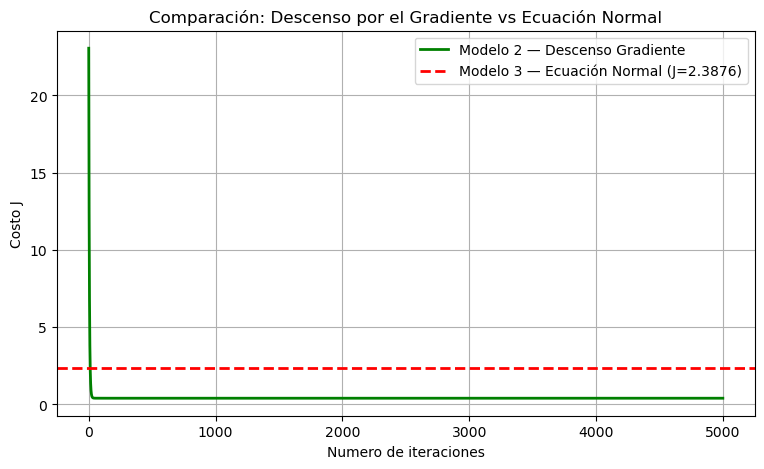

Costo final Modelo 1 (gradiente, 1 var): 0.405535
Costo final Modelo 2 (gradiente, 2 vars): 0.405489
Costo exacto Modelo 3 (ec. normal, 2 vars): 2.387613


In [20]:
# Calcular costo de la ecuación normal
J_normal = computeCostMulti(X3, y3, theta3)

pyplot.figure(figsize=(9, 5))
pyplot.plot(np.arange(len(J_history2)), J_history2, 'g-', lw=2, label='Modelo 2 — Descenso Gradiente')
pyplot.axhline(y=J_normal, color='r', linestyle='--', lw=2,
               label=f'Modelo 3 — Ecuación Normal (J={J_normal:.4f})')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparación: Descenso por el Gradiente vs Ecuación Normal')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

print(f'Costo final Modelo 1 (gradiente, 1 var): {J_history1[-1]:.6f}')
print(f'Costo final Modelo 2 (gradiente, 2 vars): {J_history2[-1]:.6f}')
print(f'Costo exacto Modelo 3 (ec. normal, 2 vars): {J_normal:.6f}')

---
## 10. Predicciones — Mínimo 100 ejemplos

Se toman **100 artículos** del dataset para realizar predicciones con los tres modelos y comparar con los valores reales.

Los valores predichos están en escala `log(1+shares)`. Se aplica la transformación inversa `expm1()` para obtener el número de shares estimado.

In [21]:
# Tomar 100 artículos del dataset para predicciones
np.random.seed(42)
idx_pred = np.random.choice(m3, 100, replace=False)

# Predicciones Modelo 1 (necesita normalización con mu, sigma del entrenamiento)
X_pred_m1 = np.zeros((100, 3))
x1_100 = df3['kw_avg_avg'].values[idx_pred]
X_pred_m1[:, 0] = 1
X_pred_m1[:, 1] = (x1_100 - mu[0]) / sigma[0]
X_pred_m1[:, 2] = (x1_100**2 - mu[1]) / sigma[1]
preds_m1 = np.expm1(np.dot(X_pred_m1, theta1))

# Predicciones Modelo 2 (normalización con mu2, sigma2)
x2_100 = df3['LDA_03'].values[idx_pred]
X_pred_m2_raw = np.column_stack([x1_100, x1_100**2, x2_100, x2_100**2])
X_pred_m2_norm = (X_pred_m2_raw - mu2) / sigma2
X_pred_m2 = np.concatenate([np.ones((100, 1)), X_pred_m2_norm], axis=1)
preds_m2 = np.expm1(np.dot(X_pred_m2, theta2))

# Predicciones Modelo 3 (ecuación normal, sin normalización)
X_pred_m3 = np.column_stack([np.ones(100), x1_100, x1_100**2, x2_100, x2_100**2])
preds_m3 = np.expm1(np.dot(X_pred_m3, theta3))

# Valores reales
reales = df3['shares'].values[idx_pred]

# Tabla de resultados
resultados = pd.DataFrame({
    'kw_avg_avg': x1_100.astype(int),
    'LDA_03': x2_100.round(3),
    'shares_real': reales,
    'pred_modelo1': preds_m1.astype(int),
    'pred_modelo2': preds_m2.astype(int),
    'pred_modelo3': preds_m3.astype(int),
})

print(f'Total de predicciones realizadas: {len(resultados)}  →  >= 100 ✓')
print('\nPrimeras 20 predicciones:')
resultados.head(20)

Total de predicciones realizadas: 100  →  >= 100 ✓

Primeras 20 predicciones:


,kw_avg_avg,LDA_03,shares_real,pred_modelo1,pred_modelo2,pred_modelo3
0,2729,0.050,2900,1636,1633,516
1,2387,0.020,1300,1518,1510,254
2,4385,0.866,17700,2297,2274,11374
3,3269,0.199,1500,1836,1858,1503
4,976,0.025,1400,1095,1094,10
5,2453,0.661,2900,1541,1565,292
6,2004,0.040,801,1393,1391,112
7,3198,0.155,3000,1809,1824,1310
8,2706,0.040,1000,1629,1623,493
9,2821,0.034,367,1670,1662,622


### 10.1 Visualización de predicciones vs valores reales

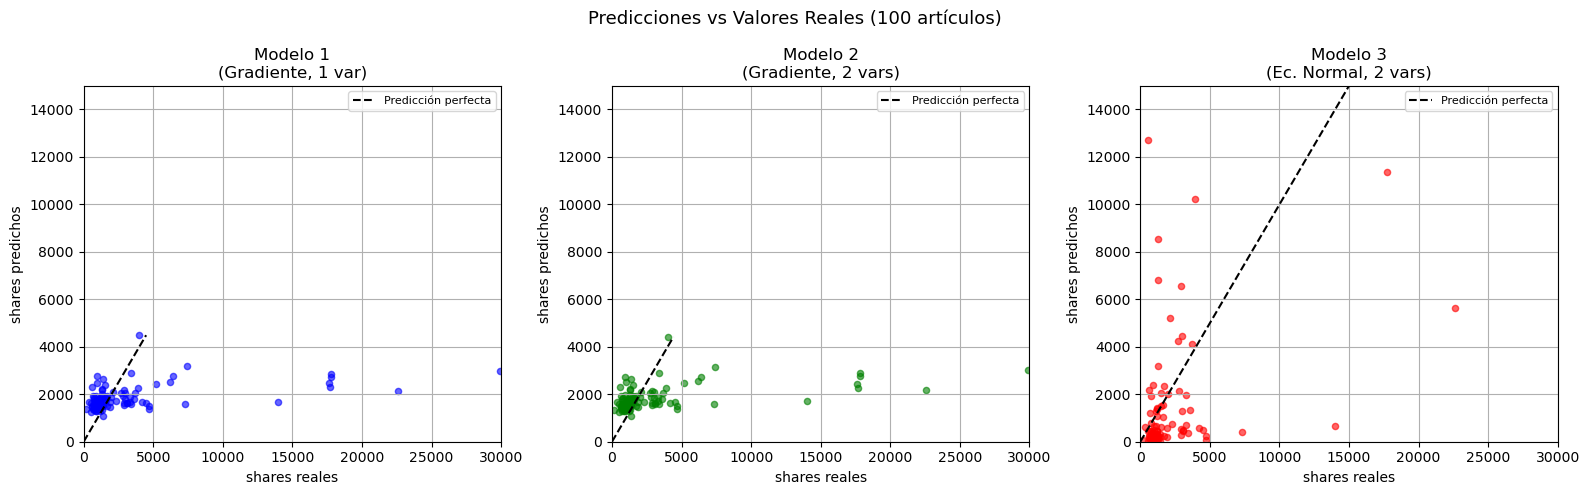

In [22]:
fig, axes = pyplot.subplots(1, 3, figsize=(16, 5))

datos = [
    (preds_m1, 'Modelo 1\n(Gradiente, 1 var)', 'blue'),
    (preds_m2, 'Modelo 2\n(Gradiente, 2 vars)', 'green'),
    (preds_m3, 'Modelo 3\n(Ec. Normal, 2 vars)', 'red')
]

for ax, (preds, titulo, color) in zip(axes, datos):
    ax.scatter(reales, preds, c=color, s=20, alpha=0.6)
    lim_max = min(reales.max(), preds.max(), 50000)
    ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('shares reales')
    ax.set_ylabel('shares predichos')
    ax.set_title(titulo)
    ax.set_xlim([0, 30000])
    ax.set_ylim([0, 15000])
    ax.legend(fontsize=8)
    ax.grid(True)

pyplot.suptitle('Predicciones vs Valores Reales (100 artículos)', fontsize=13)
pyplot.tight_layout()
pyplot.show()